# Data Preprocessing
1. Handle missing values (drop/impute/flag)
2. Convert categorical features to numeric (encoding)
3. Normalize numeric features if needed
4. Create train/test split: use May 2026 data as the test set, 
and the X months immediately preceding it as the training set. X is not fixed — 
treat the training window length as a tunable choice and experiment to determine 
the optimal value of X

The following features are the ones we have decided to use in our model:
- **Location & Neighborhood**: 'Latitude', 'Longitude', 'City', 'PostalCode', 'CountyOrParish', 'MLSAreaMajor', 'HighSchoolDistrict'
- **Property Features**: "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "YearBuilt", "Stories", "ViewYN", "PoolPrivateYN", "AttachedGarageYN", "GarageSpaces", "ParkingTotal"
- **Lot & Financial Information**: ListPrice, OriginalListPrice, LotSizeSquareFeet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
df1 = pd.read_csv('../data/CRMLSSold202505.csv')
df2 = pd.read_csv('../data/CRMLSSold202506.csv')
df3 = pd.read_csv('../data/CRMLSSold202507.csv')
df4 = pd.read_csv('../data/CRMLSSold202508.csv')
df5 = pd.read_csv('../data/CRMLSSold202509.csv')
df6 = pd.read_csv('../data/CRMLSSold202510.csv')
df7 = pd.read_csv('../data/CRMLSSold202511.csv')
df8 = pd.read_csv('../data/CRMLSSold202512.csv')
df9 = pd.read_csv('../data/CRMLSSold202601.csv')
df10 = pd.read_csv('../data/CRMLSSold202602.csv')
df11 = pd.read_csv('../data/CRMLSSold202603.csv')
df12 = pd.read_csv('../data/CRMLSSold202604.csv')
df13 = pd.read_csv('../data/CRMLSSold202605.csv')

df = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12, df13], axis=0, ignore_index=True)
df = df.drop(['ListPrice', 'OriginalListPrice'], axis=1) # note: drop ListPrice and OriginalListPrice?

# Restricting analysis according to Project Document
df = df[df['PropertyType'] == 'Residential']
df = df[df['PropertySubType'] == 'SingleFamilyResidence']

/var/folders/3l/3v_d6vqj7892stpd98hwf1ym0000gn/T/ipykernel_7995/848446542.py:2: DtypeWarning: Columns (0: WaterfrontYN) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('../data/CRMLSSold202506.csv')
/var/folders/3l/3v_d6vqj7892stpd98hwf1ym0000gn/T/ipykernel_7995/848446542.py:9: DtypeWarning: Columns (0: WaterfrontYN, 1: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df9 = pd.read_csv('../data/CRMLSSold202601.csv')


In [3]:
features = ['Latitude', 'Longitude', 'City', 'PostalCode', 'CountyOrParish', 'MLSAreaMajor', 'HighSchoolDistrict',
            "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "YearBuilt", "Stories", "ViewYN", "PoolPrivateYN", "AttachedGarageYN",
            "GarageSpaces", "ParkingTotal", 'LotSizeSquareFeet', 'ClosePrice']

df = df[features]
df = df.reset_index().drop('index', axis=1)
df.head()

,Latitude,Longitude,City,PostalCode,CountyOrParish,MLSAreaMajor,HighSchoolDistrict,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,Stories,ViewYN,PoolPrivateYN,AttachedGarageYN,GarageSpaces,ParkingTotal,LotSizeSquareFeet,ClosePrice
0,33.899427,-117.977995,Fullerton,92833,Orange,83 - Fullerton,Fullerton Joint Union High,3546.0,5.0,4.0,2003.0,2.0,True,False,True,3.0,3.0,7740.0,1800000.0
1,34.095980,-118.221993,Los Angeles,90065,Los Angeles,680 - Mount Washington,NaN,1162.0,2.0,2.0,1940.0,1.0,True,False,False,2.0,2.0,4697.0,1200000.0
2,37.313093,-122.006414,Cupertino,95014,Santa Clara,699 - Not Defined,Other,1134.0,3.0,1.0,1955.0,NaN,False,NaN,False,1.0,1.0,5775.0,2250000.0
3,33.884526,-117.778002,Yorba Linda,92886,Orange,85 - Yorba Linda,Placentia-Yorba Linda Unified,1672.0,3.0,2.0,1988.0,1.0,True,False,True,2.0,2.0,7500.0,1425000.0
4,33.169703,-117.081580,Escondido,92026,San Diego,92026 - Escondido,NaN,1286.0,3.0,3.0,1986.0,2.0,False,False,True,2.0,4.0,4552.0,660000.0


### 1. Handle missing values

In [4]:
# Percentage of values missing for each feature
values_missing = df.isnull().sum() / df.shape[0] * 100
values_missing.sort_values()

CountyOrParish            0.000000
BedroomsTotal             0.000000
ClosePrice                0.000000
ParkingTotal              0.000704
PostalCode                0.001408
Latitude                  0.009155
BathroomsTotalInteger     0.009155
Longitude                 0.009155
City                      0.034508
LivingArea                0.054931
YearBuilt                 0.068311
LotSizeSquareFeet         1.713416
GarageSpaces              3.955013
PoolPrivateYN             7.731149
ViewYN                    9.085403
Stories                  10.404445
AttachedGarageYN         12.109411
MLSAreaMajor             14.655943
HighSchoolDistrict       26.954795
dtype: float64

In [5]:
df.describe()

,Latitude,Longitude,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,Stories,GarageSpaces,ParkingTotal,LotSizeSquareFeet,ClosePrice
count,141984.000000,141984.000000,141919.000000,141997.000000,141984.000000,141900.000000,127223.000000,136381.000000,141996.000000,1.395640e+05,1.419970e+05
mean,34.732547,-118.598385,2048.649644,3.492581,2.632452,1975.809669,1.352169,2.006524,3.058514,3.710659e+05,1.344654e+06
std,1.754980,3.194440,1044.085649,0.963529,1.131934,27.606572,0.477648,3.305334,44.085262,1.744801e+07,8.084465e+06
min,-22.863239,-124.193201,0.000000,0.000000,0.000000,1776.000000,1.000000,0.000000,-35.000000,0.000000e+00,0.000000e+00
25%,33.761376,-119.145540,1386.000000,3.000000,2.000000,1956.000000,1.000000,2.000000,2.000000,5.663000e+03,6.250000e+05
50%,34.083281,-118.031083,1820.000000,3.000000,2.000000,1976.000000,1.000000,2.000000,2.000000,7.289000e+03,8.900000e+05
75%,34.784515,-117.260118,2440.000000,4.000000,3.000000,1998.000000,2.000000,2.000000,3.000000,1.045400e+04,1.425000e+06
max,43.784440,120.432670,56500.000000,22.000000,35.000000,2026.000000,2.000000,600.000000,15720.000000,1.938943e+09,9.895000e+08


Let's process **Latitude and Longitude.**

Manually input the coordinates of the cities for the null/(0, 0) Latitude and Longitude values.

In [6]:
city_coordinates = {
    'Carmel': (36.5552, -121.9233),
    'Marina': (36.6777, -121.8021),
    'Hollister': (36.8525, -121.4016),
    'Manteca': (37.7974, -121.2160),
    'Los Gatos': (37.2358, -121.9624),
    'Salinas': (36.6777, -121.6555),
    'Oakley': (37.9973, -121.7130),
    'Palmdale': (34.5794, -118.1165),
    'Napa': (38.2975, -122.2869),
    'Lancaster': (34.6868, -118.1542),
    'Fresno': (36.7378, -119.7871),
    'La Jolla': (32.8427, -117.2578),
    'Encinitas': (33.0370, -117.2920)
}

for city, (lat, lon) in city_coordinates.items():
    bm = (df['City'] == city) & (df['Latitude'].isnull() | (df['Latitude'] == 0) & (df['Longitude'] == 0))
    df.loc[bm, 'Latitude'] = lat
    df.loc[bm, 'Longitude'] = lon
    

Let us investigate properties that fall outside of California's boundary.

In [7]:
# impute lat and lon for Beaumont row, Palmdale row, Pomona row, and two rows in Carmel
df.loc[22182, 'Latitude'] = 33.9295
df.loc[22182, 'Longitude'] = -116.9772

df.loc[10256, 'Latitude'] = 34.5794
df.loc[10256, 'Longitude'] = -118.1164

df.loc[85917, 'Latitude'] = 34.0553
df.loc[85917, 'Longitude'] = -117.7523

df.loc[105037, 'Latitude'] = 36.5552
df.loc[105037, 'Longitude'] = -121.9233
df.loc[129837, 'Latitude'] = 36.5552
df.loc[129837, 'Longitude'] = -121.9233

# drop rows that are in other states and countries
df = df.drop(index=[21161, 70409, 90662, 90679], axis=0)

In [8]:
# change lon sign error for rows
df.loc[df['Longitude'] > 0, 'Longitude'] = -df.loc[df['Longitude'] > 0, 'Longitude']

# impute lat and lon for Mountain House and Palmdale rows
df.loc[39759, 'Latitude'] = 37.7794
df.loc[39759, 'Longitude'] = -121.5432

df.loc[60596, 'Latitude'] = 34.5794
df.loc[60596, 'Longitude'] = -118.116

# drop rows that are in other states and countries
df = df.drop(index=[11248, 46849, 65791], axis=0)

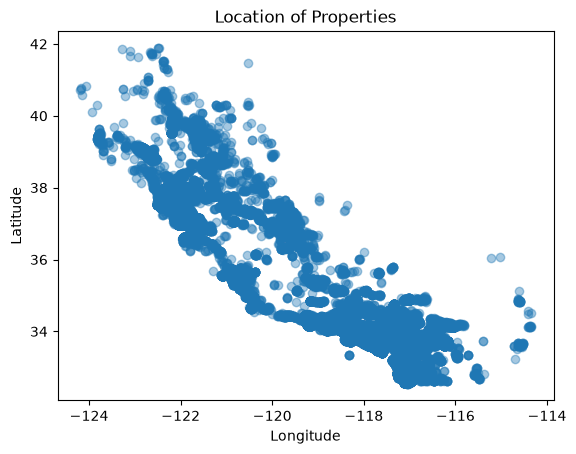

In [9]:
plt.title('Location of Properties')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.scatter(df['Longitude'], df['Latitude'], alpha=0.4);

Let's process 'City', 'PostalCode', 'CountyOrParish', 'MLSAreaMajor' (marketing area name), 'HighSchoolDistrict'.

Impute City values based on PostalCode.

In [10]:
postal_code_cities = {
    '90291': 'Venice',
    '91326': 'Porter Ranch',
    '91352-4319': 'Sun Valley',
    '92028': 'Fallbrook',
    '92037': 'La Jolla',
    '92116': 'San Diego',
    '92123': 'San Diego',
    '92277': 'Twentynine Palms',
    '92314': 'Big Bear City',
    '92399': 'Yucaipa',
    '92440': 'San Bernardino',
    '92567': 'San Jacinto',
    '93202': 'Armona',
    '93261': 'Richgrove',
    '93272': 'Tipton',
    '93506': 'Mojave',
    '93668': 'Tranquillity',
    '93908': 'Salinas',
    '93933': 'Marina',
    '94062': 'Redwood City',
    '94112': 'San Francisco',
    '94571-5507': 'Suisun City',
    '94574': 'St. Helena',
    '94578-1428': 'San Leandro',
    '94598-2356': 'Walnut Creek',
    '94940': 'Fairfax',
    '95004': 'Aromas',
    '95076': 'Watsonville',
    '95132-3226': 'San Jose',
    '95346': 'Groveland',
    '95560': 'Redway',
    '95670': 'Rancho Cordova'
}

for postal_code, city in postal_code_cities.items():
    bm = (df['PostalCode'] == postal_code) & (df['City'].isnull())
    df.loc[bm, 'City'] = city

Drop PostalCode null rows.

In [11]:
df = df[~df['PostalCode'].isnull()]

CountyOrParish is not missing any values.

Replace NaN MLSAreaMajor values with '699 - Not Defined'.

In [12]:
df['MLSAreaMajor'] = df['MLSAreaMajor'].fillna('699 - Not Defined')

There are a high amount of HighSchoolDistrict values missing. Fill in NaN values with 'Missing'.

In [13]:
df['HighSchoolDistrict'] = df['HighSchoolDistrict'].fillna('Missing')

In [14]:
# Fill boolean values with 'Unknown'
df['ViewYN'] = df['ViewYN'].fillna('Unknown')
df['PoolPrivateYN'] = df['PoolPrivateYN'].fillna('Unknown')
df['AttachedGarageYN'] = df['AttachedGarageYN'].fillna('Unknown')

### 2. Train/Test Split + Imputation

In [26]:
# the last 23260 entries should be the test set - from May 2026
train = df.iloc[0:118728]
test = df.iloc[118728:]

X_train = train.drop(['ClosePrice'], axis=1)
X_test = test.drop(['ClosePrice'], axis=1) # May 2026

Y_train = train[['ClosePrice']]
Y_test = test[['ClosePrice']] # May 2026, for accuracy

Let us use group median imputation for "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "YearBuilt", "Stories", "GarageSpaces", "ParkingTotal", "LotSizeSquareFeet". We do this separately for the train and test sets.

In [27]:
for X_df in [X_train, X_test]:
    for med_imputation in ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "YearBuilt", "Stories", "GarageSpaces", "ParkingTotal", "LotSizeSquareFeet"]:
        # Impute missing numerical values with the median value of the nearby properties (same city)
        X_df[med_imputation] = X_df.groupby('City')[med_imputation].transform(lambda sf : sf.fillna(sf.median()))
        if X_df[med_imputation].hasnans:
            X_df[med_imputation] = X_df.groupby('CountyOrParish')[med_imputation].transform(lambda sf : sf.fillna(sf.median()))
            X_df[med_imputation] = X_df[med_imputation].fillna(X_df[med_imputation].median())

In [28]:
values_missing = X_test.isnull().sum() / X_test.shape[0] * 100 # can do this for X_train too
values_missing.sort_values()

Latitude                 0.0
Longitude                0.0
City                     0.0
PostalCode               0.0
CountyOrParish           0.0
MLSAreaMajor             0.0
HighSchoolDistrict       0.0
LivingArea               0.0
BedroomsTotal            0.0
BathroomsTotalInteger    0.0
YearBuilt                0.0
Stories                  0.0
ViewYN                   0.0
PoolPrivateYN            0.0
AttachedGarageYN         0.0
GarageSpaces             0.0
ParkingTotal             0.0
LotSizeSquareFeet        0.0
dtype: float64

### 3. Encoding

Categorical features: "City", "PostalCode", "CountyOrParish", "MLSAreaMajor", "HighSchoolDistrict", "ViewYN", "PoolPrivateYN", "AttachedGarageYN"
- Nominal: City, PostalCode, CountyOrParish, MLSAreaMajor, HighSchoolDistrict
- Ordinal: N/A
- Binary (w/ 'Unknown'): ViewYN, PoolPrivateYN, AttachedGarageYN
- High-Cardinality: City, PostalCode, MLSAreaMajor, HighSchoolDistrict

Let us One-Hot Encode CountyOrParish, ViewYN, PoolPrivateYN, AttachedGarageYN. Let us use Target Encoding for the high cardinality features, City, PostalCode, MLSAreaMajor, and HighSchoolDistrict.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder

# --- Encoding ---

# convert boolean columns to string values in order for OneHotEncoder and TargetEncoder to work
for bin_col in ['ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 'PostalCode']:
    X_train[bin_col] = X_train[bin_col].astype(str)

# One hot encode both X dfs
non_ohe_cols = ['Latitude', 'Longitude', 'City', 'PostalCode', 'MLSAreaMajor', 'HighSchoolDistrict', 'LivingArea', 'BedroomsTotal',
                 'BathroomsTotalInteger', 'YearBuilt', 'Stories', 'GarageSpaces', 'ParkingTotal', 'LotSizeSquareFeet']
ohe_cols = ['CountyOrParish', 'ViewYN', 'PoolPrivateYN', 'AttachedGarageYN']

ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False) # drop='first' avoids multicolinearity --> we can use an intercept in our model
ohe.fit(X_train[ohe_cols]) # fit only on training data

X_train_ohe_array = ohe.transform(X_train[ohe_cols])
X_test_ohe_array = ohe.transform(X_test[ohe_cols])
X_train_ohe = pd.DataFrame(X_train_ohe_array, index=X_train.index, columns=ohe.get_feature_names_out(ohe_cols))
X_test_ohe = pd.DataFrame(X_test_ohe_array, index=X_test.index, columns=ohe.get_feature_names_out(ohe_cols))

X_train = pd.concat([X_train[non_ohe_cols], X_train_ohe], axis=1)
X_test = pd.concat([X_test[non_ohe_cols], X_test_ohe], axis=1)

# Target Encode both X dfs
te_cols = ['City', 'PostalCode', 'MLSAreaMajor', 'HighSchoolDistrict']

te = TargetEncoder(target_type='continuous')
te.fit(X_train[te_cols], Y_train)

X_train_te_array = te.transform(X_train[te_cols])
X_test_te_array = te.transform(X_test[te_cols])
X_train_te = pd.DataFrame(X_train_te_array, index=X_train.index, columns=te_cols)
X_test_te = pd.DataFrame(X_test_te_array, index=X_test.index, columns=te_cols)

X_train[te_cols] = X_train_te
X_test[te_cols] = X_test_te

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Now let us use these sets with a Linear Regression model.

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression() # fit_intercept=True
# log transform ClosePrice
lr.fit(X_train, np.log1p(Y_train))

lr.score(X_test, np.log1p(Y_test))

0.6180224112301402